In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score, root_mean_squared_error

In [22]:
# load datasets from games_clean and teams
clean_games = pd.read_csv('games_clean.csv')
teams = pd.read_csv('teams.csv')
X_train = pd.read_csv('train-test/X_train_diff.csv')
y_train = pd.read_csv('train-test/y_train.csv')
X_test = pd.read_csv('train-test/X_test_rol.csv')
y_test = pd.read_csv('train-test/y_test.csv')

In [23]:
clean_games

,GAME_ID,GAME_DATE_EST,SEASON,NICKNAME_home,NICKNAME_away,TEAM_ID_home,TEAM_ID_away,PTS_roll10_home,FG_PCT_roll10_home,FT_PCT_roll10_home,FG3_PCT_roll10_home,AST_roll10_home,REB_roll10_home,PTS_roll10_away,FG_PCT_roll10_away,FT_PCT_roll10_away,FG3_PCT_roll10_away,AST_roll10_away,REB_roll10_away,POINT_DIFF
0,20300127,2003-11-15,2003,Wizards,Spurs,1610612764,1610612759,92.8,0.4395,0.7134,0.3308,20.6,44.6,86.4,0.3806,0.7503,0.2891,18.3,46.8,-24.0
1,20300128,2003-11-15,2003,Hawks,Nets,1610612737,1610612751,89.4,0.4327,0.7390,0.3765,20.1,44.0,86.0,0.4149,0.7358,0.3413,23.9,40.2,-15.0
2,20300130,2003-11-15,2003,Cavaliers,76ers,1610612739,1610612755,89.5,0.4405,0.6874,0.3291,23.3,45.7,93.2,0.4382,0.7238,0.3170,19.6,38.3,3.0
3,20300136,2003-11-16,2003,Raptors,Rockets,1610612761,1610612745,75.3,0.3821,0.7709,0.2969,17.8,40.8,87.7,0.4390,0.7576,0.3872,17.4,41.7,4.0
4,20300139,2003-11-17,2003,76ers,Rockets,1610612755,1610612745,94.1,0.4390,0.7082,0.3209,20.5,38.9,89.4,0.4289,0.7770,0.3789,17.5,42.4,-8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26556,22200474,2022-12-21,2022,Thunder,Trail Blazers,1610612760,1610612757,114.9,0.4619,0.8106,0.3594,24.3,45.4,118.4,0.4992,0.7934,0.3991,24.7,43.9,3.0
26557,22200475,2022-12-21,2022,Kings,Lakers,1610612758,1610612747,115.6,0.4783,0.7720,0.3434,25.2,44.2,119.1,0.4932,0.7803,0.3441,25.2,43.8,14.0
26558,22200476,2022-12-21,2022,Clippers,Hornets,1610612746,1610612766,107.1,0.4216,0.7641,0.3739,21.2,47.3,114.1,0.4428,0.7642,0.3311,23.0,46.7,21.0
26559,22200477,2022-12-22,2022,Pelicans,Spurs,1610612740,1610612759,118.7,0.4896,0.7884,0.3460,26.7,45.0,112.5,0.4789,0.7387,0.3508,26.1,43.4,9.0


In [24]:
# naive baseline
naive_predictions = np.full(len(y_test), y_train.mean())
naive_mse = np.mean((naive_predictions - y_test.values.flatten()) ** 2)
naive_rmse = np.sqrt(np.mean((naive_predictions - y_test.values.flatten()) ** 2))
naive_accuracy = np.mean((naive_predictions > 0) == (y_test.values.flatten() > 0))

print(f"Naive Baseline MSE: {naive_mse:.4f}")
print(f"Naive Baseline RMSE: {naive_rmse:.4f}")
print(f"Naive Baseline Accuracy: {naive_accuracy:.4f}")

Naive Baseline MSE: 237.2974
Naive Baseline RMSE: 15.4045
Naive Baseline Accuracy: 0.5218


In [25]:
# OLS baseline

X_train_ols = np.hstack([X_train.values, np.ones((X_train.shape[0], 1))])
X_test_ols = np.hstack([X_test.values, np.ones((X_test.shape[0], 1))])

beta_ols = np.linalg.lstsq(X_train_ols, y_train.values.flatten(), rcond=None)[0]

ols_predictions = X_test_ols @ beta_ols
ols_mse = np.mean((ols_predictions - y_test.values.flatten()) ** 2)
ols_rmse = np.sqrt(np.mean((ols_predictions - y_test.values.flatten()) ** 2))
ols_accuracy = np.mean((ols_predictions > 0) == (y_test.values.flatten() > 0))

print(f"OLS Baseline MSE: {ols_mse:.4f}")
print(f"OLS Baseline RMSE: {ols_rmse:.4f}")
print(f"OLS Baseline Accuracy: {ols_accuracy:.4f}")

OLS Baseline MSE: 242.1087
OLS Baseline RMSE: 15.5598
OLS Baseline Accuracy: 0.5207


In [26]:
# only train off the first 6 columns of X_train
X_train_subset = X_train.iloc[:, :6]

In [27]:
# MLP Implementation
np.random.seed(42)
eta = 0.01 # learning rate
num_epochs = 1000
layer_dimensions = [6, 64, 16, 1]
# layer_dimensions = [35, 32, 16, 1]
# layer_dimensions = [64, 32, 16, 1]

# initializing weights from normal distribution
# using He initialization to allow variance to stay roughly constant between layers
# (without that the loss was not converging)
W1 = np.random.normal(size=(layer_dimensions[0], layer_dimensions[1])) * np.sqrt(2.0/layer_dimensions[0])
W2 = np.random.normal(size=(layer_dimensions[1], layer_dimensions[2])) * np.sqrt(2.0/layer_dimensions[1])
W3 = np.random.normal(size=(layer_dimensions[2], layer_dimensions[3])) * np.sqrt(2.0/layer_dimensions[2])

# bias terms for each layer
b1 = np.zeros((layer_dimensions[1], 1))
b2 = np.zeros((layer_dimensions[2], 1))
b3 = np.zeros((layer_dimensions[3], 1))

In [28]:
# ReLU activation function - used for all hidden layers
def relu(X):
    return np.maximum(X, 0)

def relu_derivative(X):
    return (X > 0).astype(float)

In [29]:
# forward pass
def forward(X, W1, b1, W2, b2, W3, b3):
    z1 = np.dot(W1.T, X) + b1
    h1 = relu(z1)
    z2 = np.dot(W2.T, h1) + b2
    h2 = relu(z2)
    z3 = np.dot(W3.T, h2) + b3 # fw_x
    return z1, h1, z2, h2, z3.flatten()

In [30]:
# loss function: MSE
# using half MSE instead of full MSE since it cancels out the 2 in the derivative of MSE

def mse_loss(y, fw_x):
    fw_x_flat = fw_x.flatten()
    y_flat = y.flatten()
    return 1/len(fw_x) * np.sum((fw_x_flat - y_flat) ** 2)

In [31]:
# backprop

def dLdW1(X, y, W2, W3, z1, z2, fw_x):
    n = X.shape[1]
    err = fw_x - y
    d_relu2 = relu_derivative(z2)
    d_relu1 = relu_derivative(z1)

    dL_dz3 = err.reshape(1, -1)/n
    dL_dh2 = W3 @ dL_dz3
    dL_dz2 = dL_dh2 * d_relu2
    dL_dh1 = W2 @ dL_dz2
    dL_dz1 = dL_dh1 * d_relu1
    dL_dw1 = X @ dL_dz1.T
    dL_db1 = dL_dz1.sum(axis=1, keepdims=True)

    return dL_dw1, dL_db1

def dLdW2(X, y, W3, h1, z2, fw_x):
    n = X.shape[1]
    err = fw_x - y
    d_relu = relu_derivative(z2)

    dL_dz3 = err.reshape(1, -1)/n
    dL_dh2 = W3 @ dL_dz3
    dL_dz2 = dL_dh2 * d_relu
    dL_dw2 = h1 @ dL_dz2.T
    dL_db2 = dL_dz2.sum(axis=1, keepdims=True)

    return dL_dw2, dL_db2

def dLdW3(X, y, h2, fw_x):
    n = X.shape[1]
    err = fw_x - y
    dL_dz3 = err.reshape(1, -1)/n
    dL_dw3 = h2 @ dL_dz3.T
    dL_db3 = dL_dz3.sum(keepdims=True)

    return dL_dw3, dL_db3

In [32]:
def update_weights_with_l2(weight, gradient, n, lam=0.01):
    return weight - eta * (gradient + lam/n * weight)

In [33]:
# Training loop
losses = []

def train_mlp(X_train, y_train, W1, W2, W3, b1, b2, b3):
    for epoch in range(num_epochs):
        # forward pass
        z1, h1, z2, h2, fw_x = forward(X_train, W1, b1, W2, b2, W3, b3)

        # find loss after forward pass
        loss = mse_loss(y=y_train, fw_x=fw_x)
        losses.append(loss)

        # backprop
        dL_dw1, dL_db1 = dLdW1(X_train, y_train, W2, W3, z1, z2, fw_x)
        dL_dw2, dL_db2 = dLdW2(X_train, y_train, W3, h1, z2, fw_x)
        dL_dw3, dL_db3 = dLdW3(X_train, y_train, h2, fw_x)

        n = X_train.shape[1]

        # W1 = update_weights_with_l2(W1, dL_dw1, n)
        # W2 = update_weights_with_l2(W2, dL_dw2, n)
        # W3 = update_weights_with_l2(W3, dL_dw3, n)
        W1 = W1 - eta * dL_dw1
        W2 = W2 - eta * dL_dw2
        W3 = W3 - eta * dL_dw3
        b1 = b1 - eta * dL_db1
        b2 = b2 - eta * dL_db2
        b3 = b3 - eta * dL_db3

        if epoch % 100 == 0:
            print(f'Epoch {epoch}: Loss = {loss:.4f}')

    return W1, W2, W3, b1, b2, b3

In [34]:
W1_final, W2_final, W3_final, b1_final, b2_final, b3_final = train_mlp(X_train_subset.values.T, y_train.values.flatten(), W1, W2, W3, b1, b2, b3)
print("Final W1:", W1_final)
print("Final W2:", W2_final)
print("Final W3:", W3_final)

Epoch 0: Loss = 201.7484
Epoch 100: Loss = 184.3289
Epoch 200: Loss = 183.6991
Epoch 300: Loss = 183.1484
Epoch 400: Loss = 182.6466
Epoch 500: Loss = 182.1442
Epoch 600: Loss = 181.6558
Epoch 700: Loss = 181.1021
Epoch 800: Loss = 180.4978
Epoch 900: Loss = 180.3776
Final W1: [[ 2.46082573e-01 -2.18456622e-01  4.54926945e-01  7.57156985e-01
   3.39271287e-02 -1.41383871e-01  1.05161232e+00  5.85778014e-01
  -2.30823323e-01  3.59417203e-01 -3.13049115e-01 -4.08764639e-01
   2.43781704e-01 -1.09641390e+00 -1.02242825e+00 -2.95234468e-01
  -6.36576466e-01  2.26429070e-01 -5.88091647e-01 -7.28953437e-01
   9.45801920e-01 -9.28977819e-02  2.05280445e-01 -7.62971681e-01
  -2.69851608e-01 -3.13028373e-03 -7.08628907e-01  2.30680899e-01
  -1.90198662e-01 -3.51850237e-01 -4.99639369e-01  1.09332899e+00
  -7.30208571e-03 -6.39104280e-01  4.90495526e-01 -6.58204863e-01
   1.90449342e-01 -1.09419639e+00 -7.55164012e-01  3.68081293e-02
   4.73819789e-01  1.47746158e-01  6.80828890e-02 -2.69610955e

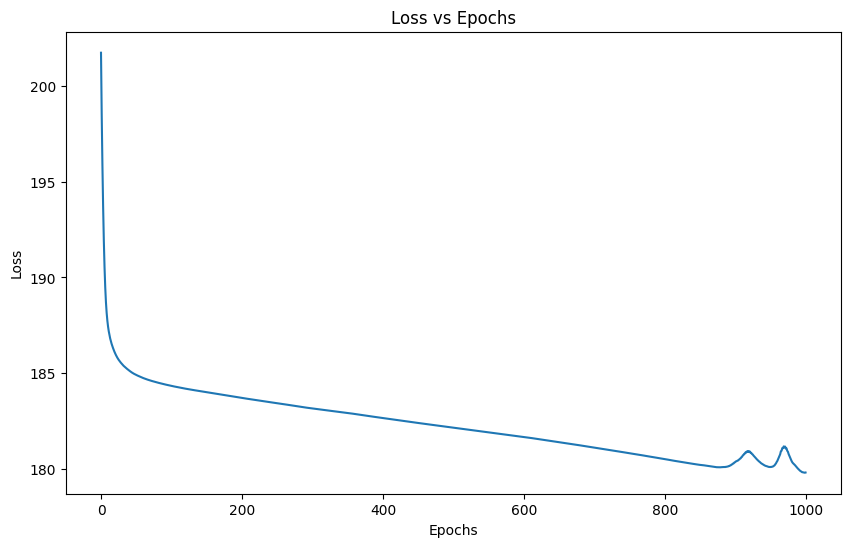

In [35]:
# plotting
plt.figure(figsize=(10,6))
plt.plot(losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.show()

In [36]:
# predicting using x_test
X_test_subset = X_test.iloc[:, :6]
_, _, _, _, y_pred = forward(X_test_subset.values.T, W1_final, b1_final, W2_final, b2_final, W3_final, b3_final)

In [37]:
predictions_df = pd.DataFrame({'Predicted': y_pred, 'Actual': y_test.values.flatten()})
predictions_df

,Predicted,Actual
0,6.615807,-4.0
1,-3.205490,-6.0
2,3.730172,-21.0
3,0.595110,6.0
4,-0.707950,25.0
...,...,...
865,-3.319719,-13.0
866,1.036074,12.0
867,2.364836,4.0
868,-3.766589,5.0


In [38]:
y_true = y_test.values
print(mean_absolute_error(y_true=y_true, y_pred=y_pred))
print(mean_absolute_percentage_error(y_true=y_true, y_pred=y_pred))
print(mean_squared_error(y_true=y_true, y_pred=y_pred))
print(root_mean_squared_error(y_true=y_true, y_pred=y_pred))
print(r2_score(y_true=y_true, y_pred=y_pred))

11.650500125941395
1.0987426191108187
220.59757879762742
14.852527690518789
0.05049764936517265


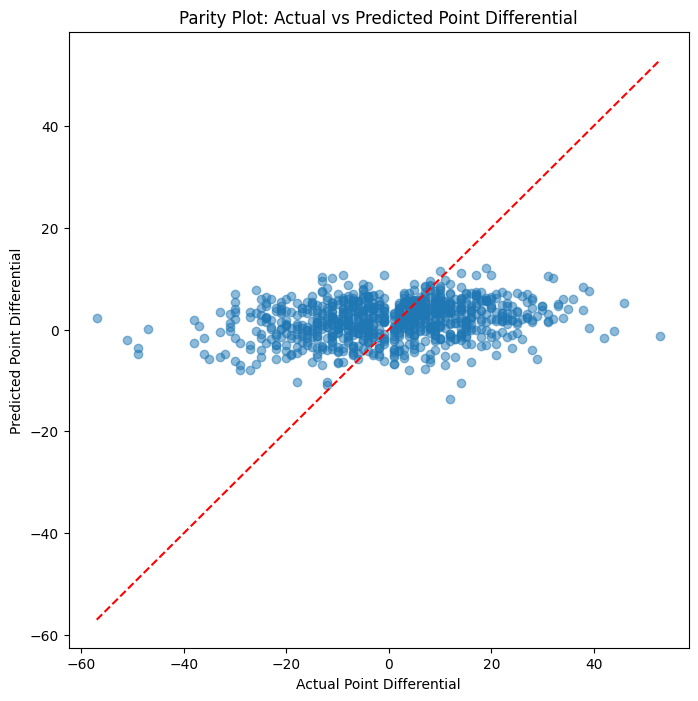

In [39]:
plt.figure(figsize=(8,8))
plt.scatter(y_test.values.flatten(), y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Point Differential')
plt.ylabel('Predicted Point Differential')
plt.title('Parity Plot: Actual vs Predicted Point Differential')
plt.show()

In [40]:
np.mean((y_pred > 0) == (y_test.values.flatten() > 0))

np.float64(0.5827586206896552)